# Navi – Probability of Default (PD) Prediction

**What this does:** Predict the probability of default for `type = 'oot'` decisions using a model trained on `type = 'train'` decisions.

---
**Notebook Structure**

| # | Section |
|---|---|
| 1 | Exploratory Data Analysis (EDA) |
| 2 | Feature Engineering from Transactions |
| 3 | Dataset Assembly & Train/OOT Split |
| 4 | Pre-processing & Feature Selection |
| 5 | Model Building |
| 6 | Model Evaluation |
| 7 | Threshold Selection |
| 8 | OOT Prediction |
| 9 | Model Inference |

In [ ]:
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR = Path('data')
OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
print('import success')

All imports successful.


In [ ]:
flag_base = pd.read_csv(
    DATA_DIR / 'assignment_flag_base.csv',
    parse_dates=['decision_date', 'decision_date_full']
)

txn_ledger = pd.read_csv(
    DATA_DIR / 'assignment_txn_ledger.csv',
    parse_dates=['decision_date', 'txnDate']
)

print(f'flag_base: {flag_base.shape[0]:,} rows  × {flag_base.shape[1]} cols')
print(f'txn_ledger: {txn_ledger.shape[0]:,} rows  × {txn_ledger.shape[1]} cols')

# just to see if load success
flag_base.head()

flag_base  : 51,068 rows  × 5 cols
txn_ledger : 3,779,583 rows  × 8 cols


,decision_id,decision_date,decision_date_full,default,type
0,b3e8cbd1-f940-4216-9ba2-a8cca1cbb791,2024-09-15,2024-09-15 03:37:37,NaN,oot
1,1a5b48c4-f715-4de6-af2f-025daa4598ba,2023-11-15,2023-11-15 11:10:30.723057,0.0,train
2,3dabb0db-2c29-4a93-8a8c-784607a9f639,2023-01-10,2023-01-10 10:28:33.406657,1.0,train
3,a40af4f7-7890-4a0b-8895-7034394992c2,2023-12-22,2023-12-22 08:12:16.694638,1.0,train
4,19d5e4fb-d045-4033-b3c4-88507acf43ab,2023-11-18,2023-11-18 18:37:35.601235,0.0,train


In [3]:
print('flag_base type distribution')
print(flag_base['type'].value_counts(), '\n')

print('Default rate in train set')
train_df = flag_base[flag_base['type'] == 'train'].copy()
print(train_df['default'].value_counts(normalize=True).round(4), '/n')

# print('flag_base dtypes', flag_base.dtypes, '\n')
# print('txn_ledger dtypes', txn_ledger.dtypes)

flag_base type distribution
type
train    45027
oot       6041
Name: count, dtype: int64 

Default rate in train set
default
0.0    0.8969
1.0    0.1031
Name: proportion, dtype: float64 /n


## EDA of sorts

In [ ]:
# distrivution check
train_df['default'].value_counts()

default
0.0    40384
1.0     4643
Name: count, dtype: int64

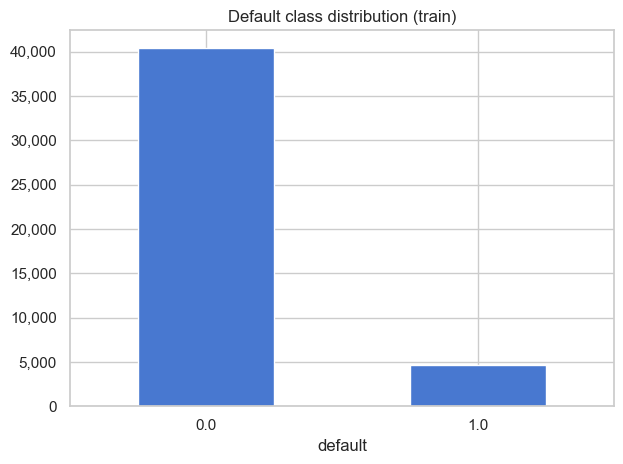

Overall default rate: 10.31%


In [4]:
# Check for class imbalance, which iss standaerd for default cases
ax = train_df['default'].value_counts().plot(
    kind='bar', title='Default class distribution (train)', rot=0
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

default_rate = train_df['default'].mean()
print(f'Overall default rate: {default_rate:.2%}')

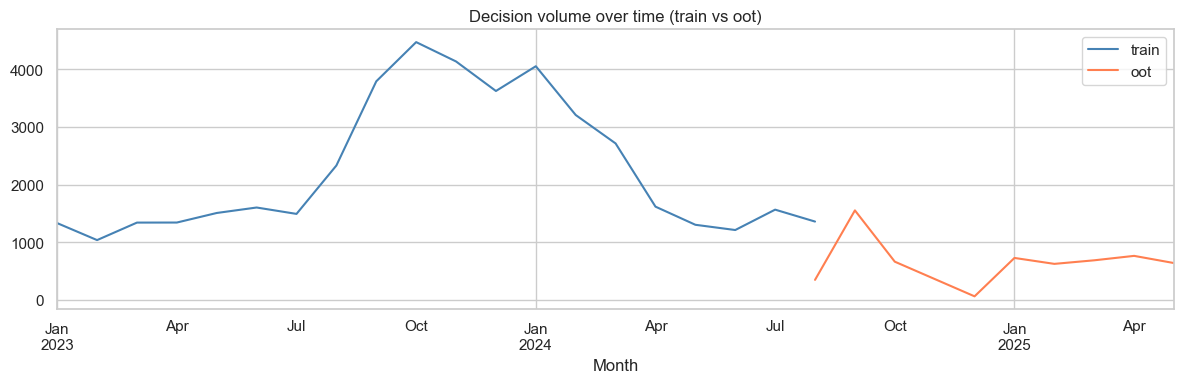

OOT samples are more recent


In [5]:
# Decision date: train and OOT
fig, ax = plt.subplots(figsize=(12, 4))
for label, color in [('train', 'steelblue'), ('oot', 'coral')]:
    sub = flag_base[flag_base['type'] == label]
    sub['decision_date'].dt.to_period('M').value_counts().sort_index().plot(
        ax=ax, label=label, color=color
    )
ax.set_title('Decision volume over time (train vs oot)')
ax.set_xlabel('Month')
ax.legend()
plt.tight_layout()
plt.show()
print('OOT samples are more recent')

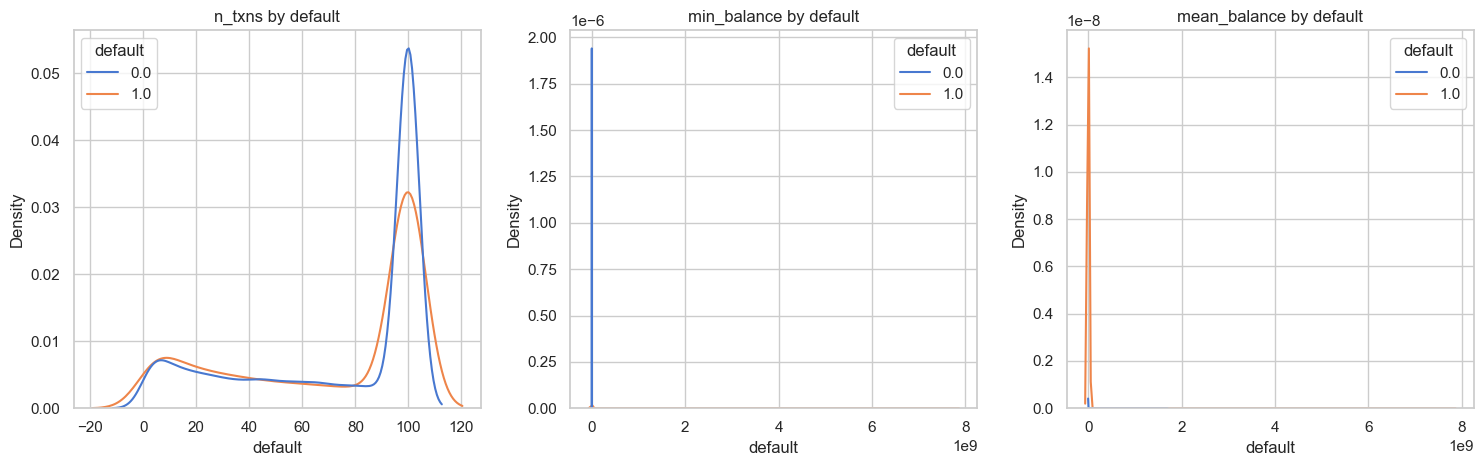

In [6]:
# Transaction level statistics per decision
txn_stats = txn_ledger.groupby('decision_id').agg(
    n_txns      = ('txnDate', 'count'),
    n_accounts  = ('bankAccount', 'nunique'),
    total_debit = ('debit', 'sum'),
    total_credit= ('credit', 'sum'),
    min_balance = ('balance', 'min'),
    max_balance = ('balance', 'max'),
    mean_balance= ('balance', 'mean'),
).reset_index()

# merge with train labels
eda_merged = train_df.merge(txn_stats, on='decision_id', how='left')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['n_txns', 'min_balance', 'mean_balance']):
    sns.kdeplot(data=eda_merged, x=col, hue='default', common_norm=False, ax=ax)
    ax.set_title(f'{col} by default')
    ax.set_xlabel('default')
plt.suptitle('')
plt.tight_layout()
plt.show()

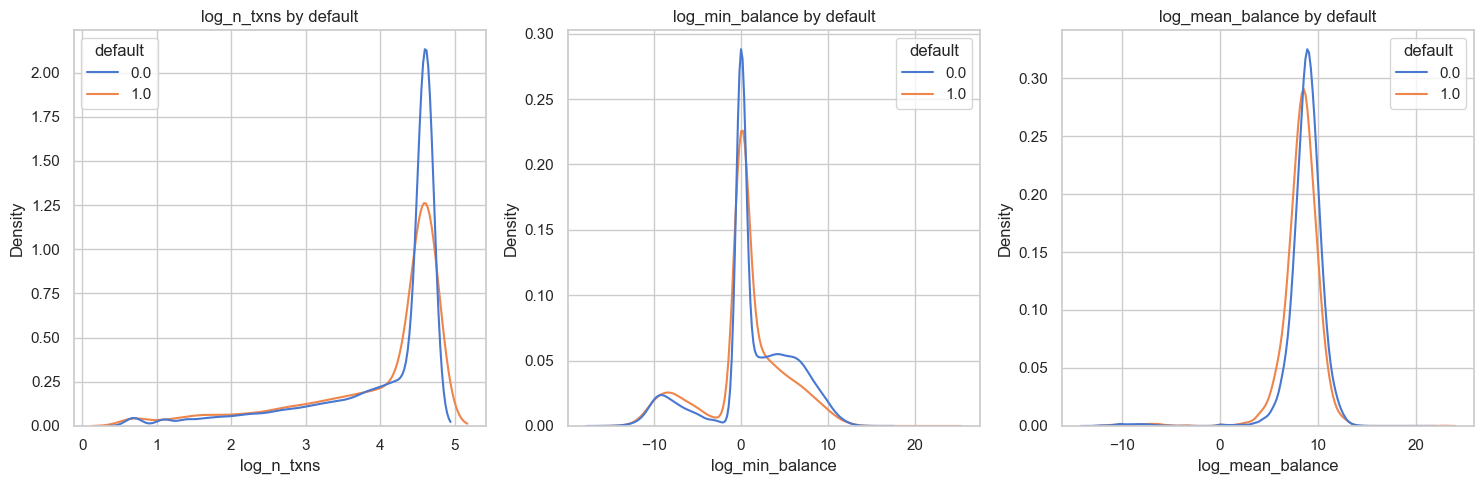

In [7]:
eda_merged['log_n_txns'] = np.log1p(eda_merged['n_txns'])
eda_merged['log_min_balance'] = np.sign(eda_merged['min_balance']) * np.log1p(np.abs(eda_merged['min_balance']))
eda_merged['log_mean_balance'] = np.sign(eda_merged['mean_balance']) * np.log1p(np.abs(eda_merged['mean_balance']))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['log_n_txns', 'log_min_balance', 'log_mean_balance']):
    sns.kdeplot(data=eda_merged, x=col, hue='default', common_norm=False, ax=ax)
    ax.set_title(f'{col} by default')

plt.tight_layout()
plt.show()

- default cases have less number of transactions
- min balance and mean balance do not have any stark differentiators between the two clases, weak signal

In [8]:
summary_stats = eda_merged.groupby('default')[['n_txns', 'min_balance', 'mean_balance']].describe()
display(summary_stats.T)

default                      0.0           1.0
n_txns       count  4.038400e+04  4.643000e+03
             mean   7.373182e+01  7.066466e+01
             std    3.499721e+01  3.672085e+01
             min    1.000000e+00  1.000000e+00
             25%    4.400000e+01  3.500000e+01
             50%    1.000000e+02  1.000000e+02
             75%    1.000000e+02  1.000000e+02
             max    1.000000e+02  1.000000e+02
min_balance  count  3.865400e+04  4.303000e+03
             mean  -5.485543e+02  1.811509e+06
             std    8.059651e+04  1.188651e+08
             min   -9.242332e+06 -9.175375e+05
             25%    0.000000e+00  0.000000e+00
             50%    0.000000e+00  0.000000e+00
             75%    9.636000e+01  1.694000e+01
             max    7.990982e+06  7.797224e+09
mean_balance count  3.865400e+04  4.303000e+03
             mean   7.248006e+04  1.824775e+06
             std    8.830722e+06  1.188649e+08
             min   -7.224390e+05 -1.408446e+05
             25%    3.189269e+03  1.791832e+03
             50%    7.461694e+03  4.607983e+03
             75%    1.695987e+04  1.125150e+04
             max    1.693509e+09  7.797225e+09

In [ ]:
# Merge decision_date into ledger for look-back window calculations
decision_dates = flag_base[['decision_id', 'decision_date']].drop_duplicates()
ledger = txn_ledger.merge(decision_dates, on='decision_id', how='left', suffixes=('', '_flag'))

ledger['days_before'] = (ledger['decision_date'] - ledger['txnDate']).dt.days

# keep only transactions up to (and including) decision date
ledger = ledger[ledger['days_before'] >= 0]

print(f'Ledger rows after leakage filter: {len(ledger):,}')
ledger.head()

Ledger rows after leakage filter: 3,365,676


,decision_id,decision_date,bankAccount,txnDate,txnTimestamp,debit,credit,balance,decision_date_flag,days_before
9,025d1f0f-dc17-44f6-8e5c-b5e70543dd3c,2024-10-11,union bank of india_account_xx64,2024-10-11,1728666010626,NaN,30000.0,31507.32,2024-10-11,0
10,025d1f0f-dc17-44f6-8e5c-b5e70543dd3c,2024-10-11,state bank of india_account_xx92,2024-10-11,1728625489011,320.0,NaN,6010.07,2024-10-11,0
11,025d1f0f-dc17-44f6-8e5c-b5e70543dd3c,2024-10-11,union bank of india_account_xx64,2024-10-08,1728357059788,10700.0,NaN,1507.32,2024-10-11,3
12,025d1f0f-dc17-44f6-8e5c-b5e70543dd3c,2024-10-11,bank of india_account_xx10,2024-10-08,1728357059788,10000.0,NaN,1009.60,2024-10-11,3
13,025d1f0f-dc17-44f6-8e5c-b5e70543dd3c,2024-10-11,bank of india_account_xx10,2024-10-07,1728268578671,10000.0,NaN,11009.60,2024-10-11,4


In [ ]:
def build_features(ledger: pd.DataFrame, window_days: int = None) -> pd.DataFrame:
    # Aggregate transaction ledger into one row per decision_id.
    df = ledger.copy()
    if window_days is not None:
        df = df[df['days_before'] <= window_days]

    agg = df.groupby('decision_id').agg(
        # Volume related features
        n_txns              = ('txnDate', 'count'),
        n_accounts          = ('bankAccount', 'nunique'),
        n_debit_txns        = ('debit', lambda x: x.notna().sum()),
        n_credit_txns       = ('credit', lambda x: x.notna().sum()),

        # Debit related features
        total_debit         = ('debit', 'sum'),
        mean_debit          = ('debit', 'mean'),
        max_debit           = ('debit', 'max'),

        # Credit related features
        total_credit        = ('credit', 'sum'),
        mean_credit         = ('credit', 'mean'),
        max_credit          = ('credit', 'max'),

        # Balance relatd features
        min_balance         = ('balance', 'min'),
        max_balance         = ('balance', 'max'),
        mean_balance        = ('balance', 'mean'),
        last_balance        = ('balance', 'last'),
        std_balance         = ('balance', 'std'),

        # Recency
        days_since_last_txn = ('days_before', 'min'),
        days_since_first_txn= ('days_before', 'max'),
        txn_span_days       = ('days_before', lambda x: x.max() - x.min()),
    ).reset_index()

    # ratios, these might not make sense
    agg['credit_debit_ratio']   = agg['total_credit'] / (agg['total_debit'] + 1e-9)
    agg['balance_range']        = agg['max_balance'] - agg['min_balance']
    agg['debit_txn_ratio']      = agg['n_debit_txns'] / (agg['n_txns'] + 1e-9)
    agg['negative_balance_flag']= (agg['min_balance'] < 0).astype(int)

    suffix = f'_w{window_days}d' if window_days else ''
    rename_map = {c: c + suffix for c in agg.columns if c != 'decision_id'}
    return agg.rename(columns=rename_map)


# All-time features + 30-day / 90-day rolling windows
feat_all  = build_features(ledger)
feat_30d  = build_features(ledger, window_days=30)
feat_90d  = build_features(ledger, window_days=90)

print(f'feat_all  : {feat_all.shape}')   
print(f'feat_30d  : {feat_30d.shape}')
print(f'feat_90d  : {feat_90d.shape}')

feat_all  : (50901, 23)
feat_30d  : (50003, 23)
feat_90d  : (50901, 23)


-- how do we validate the new features make any sense
especially the ratios

## Dataset Assembly + Train / OOT Split

In [11]:
master = flag_base.copy()
for feat_df in [feat_all, feat_30d, feat_90d]:
    master = master.merge(feat_df, on='decision_id', how='left')

# temporal features from flag_base itself
master['decision_date'] = pd.to_datetime(master['decision_date'], errors='coerce')
master['decision_date_full'] = pd.to_datetime(master['decision_date_full'], errors='coerce')

master['decision_month']     = master['decision_date'].dt.month
master['decision_dayofweek'] = master['decision_date'].dt.dayofweek
master['decision_hour']      = master['decision_date_full'].dt.hour

train = master[master['type'] == 'train'].copy()
oot   = master[master['type'] == 'oot'].copy()

TARGET = 'default'
DROP_COLS = ['decision_id', 'decision_date', 'decision_date_full', 'type', TARGET]

X_train = train.drop(columns=DROP_COLS)
y_train = train[TARGET].astype(int)

X_oot   = oot.drop(columns=DROP_COLS, errors='ignore')

print(f'X_train: {X_train.shape}  |  class balance: {y_train.mean():.2%} default')
print(f'X_oot  : {X_oot.shape}')

X_train: (45027, 69)  |  class balance: 10.31% default
X_oot  : (6041, 69)


## Pre-processing & Feature Selection

**Steps:**
1. Median imputation for numerical features (transactions missing = 0 records → NaN fill is meaningful)
2. Standard scaling (required for logistic regression; tree models are scale-invariant, included just for uniformity)

In [ ]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
])

print(f'Number of numeric features: {len(numeric_features)}')
print("10 numeric features")
print(numeric_features[:10])

Number of numeric features: 69
['n_txns', 'n_accounts', 'n_debit_txns', 'n_credit_txns', 'total_debit', 'mean_debit', 'max_debit', 'total_credit', 'mean_credit', 'max_credit'] ...


In [ ]:
# Null chdeck before imputation
null_pct = X_train[numeric_features].isnull().mean().sort_values(ascending=False)
print('Features with >20% nulls (candidates for drop):')
print(null_pct[null_pct > 0.2].to_string())
print()

#  Flag features: decisions with zero transaction history (no match in ledger)
"""
Median impute is used becuase
1. does not change median
2. zero impute would bring a lot more attention to the zero values, weakening a signal, if any
"""
no_txn_pct = (X_train['n_txns'].isna()).mean()
print(f'Decisions with no transaction history: {no_txn_pct:.2%}')

Features with >20% nulls (candidates for drop):
decision_hour    0.824439

Decisions with no transaction history: 0.28%
Reasoning: Median imputation preserves distributional centre;
zero-fill would conflate missing with truly zero-activity.


## Model Building

### Algorithm Choice

| Model | Rationale |
|---|---|
| **Logistic Regression** | Interpretable baseline; outputs reasonably calibrated PDs; fast. |
| **Random Forest** | Captures non-linearities and interactions; explainable via feature importances / permutation importance. |

**Class imbalance handling:** `class_weight='balanced'` to avoid resampling and keep probability behaviour stable.

**Evaluation metric:** **ROC-AUC** during CV (rank-ordering quality); **PR-AUC** as secondary metric to stress-test minority class recall.

In [14]:
models = {
    'LogisticRegression': Pipeline([
        ('pre',   preprocessor),
        ('clf',   LogisticRegression(
            max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE
        ))
    ]),

    'RandomForest': Pipeline([
        ('pre',   preprocessor),
        ('clf',   RandomForestClassifier(
            n_estimators=500, max_depth=8, min_samples_leaf=25,
            class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
        ))
    ]),
}

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, pipe in models.items():
    roc_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    pr_scores  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=-1)
    cv_results[name] = {
        'roc_auc_mean': roc_scores.mean(),
        'roc_auc_std' : roc_scores.std(),
        'pr_auc_mean' : pr_scores.mean(),
        'pr_auc_std'  : pr_scores.std(),
    }
    print(f'{name:25s}  ROC-AUC: {roc_scores.mean():.4f} ± {roc_scores.std():.4f}  |  PR-AUC: {pr_scores.mean():.4f} ± {pr_scores.std():.4f}')

results_df = pd.DataFrame(cv_results).T.sort_values('roc_auc_mean', ascending=False)
print('\nBest model by ROC-AUC:', results_df.index[0])

LogisticRegression         ROC-AUC: 0.6013 ± 0.0127  |  PR-AUC: 0.1375 ± 0.0057
RandomForest               ROC-AUC: 0.6380 ± 0.0115  |  PR-AUC: 0.1658 ± 0.0038

Best model by ROC-AUC: RandomForest


In [24]:
# just checking results if it matches what is printed above
results_df

,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
RandomForest,0.637957,0.011487,0.165774,0.003811
LogisticRegression,0.601298,0.012739,0.137528,0.005703


In [16]:
# Train on full training set
best_model_name = results_df.index[0]
final_model = models[best_model_name]
final_model.fit(X_train, y_train)
print(f'Final model :{best_model_name} trained on {len(X_train):,} samples.')

Final model (RandomForest) trained on 45,027 samples.


## Model Evaluation

**Why ROC-AUC?**
ROC-AUC measures the model's ability to *rank* defaulters above non-defaulters, independent of any threshold. 

**Why PR-AUC as secondary?**
With a heavily imbalanced dataset, PR-AUC is more informative than ROC-AUC about performance on the minority (default) class, since it focuses on precision and recall of positive predictions.

**Why NOT accuracy?**
A model predicting all non-default would achieve ~95%+ accuracy while being uselessc
(accuracy is misleading for imbalanced classes)

In [17]:
# Re-fit with a held-out validation slice for plotting (last 20% chronologically)
train_sorted = train.sort_values('decision_date')
split_idx    = int(len(train_sorted) * 0.8)

X_tr  = train_sorted.iloc[:split_idx].drop(columns=DROP_COLS)
y_tr  = train_sorted.iloc[:split_idx][TARGET].astype(int)
X_val = train_sorted.iloc[split_idx:].drop(columns=DROP_COLS)
y_val = train_sorted.iloc[split_idx:][TARGET].astype(int)

eval_model = models[best_model_name]
eval_model.fit(X_tr, y_tr)

y_prob = eval_model.predict_proba(X_val)[:, 1]

print(f'Hold-out ROC-AUC : {roc_auc_score(y_val, y_prob):.4f}')
print(f'Hold-out PR-AUC  : {average_precision_score(y_val, y_prob):.4f}')

Hold-out ROC-AUC : 0.6310
Hold-out PR-AUC  : 0.1421


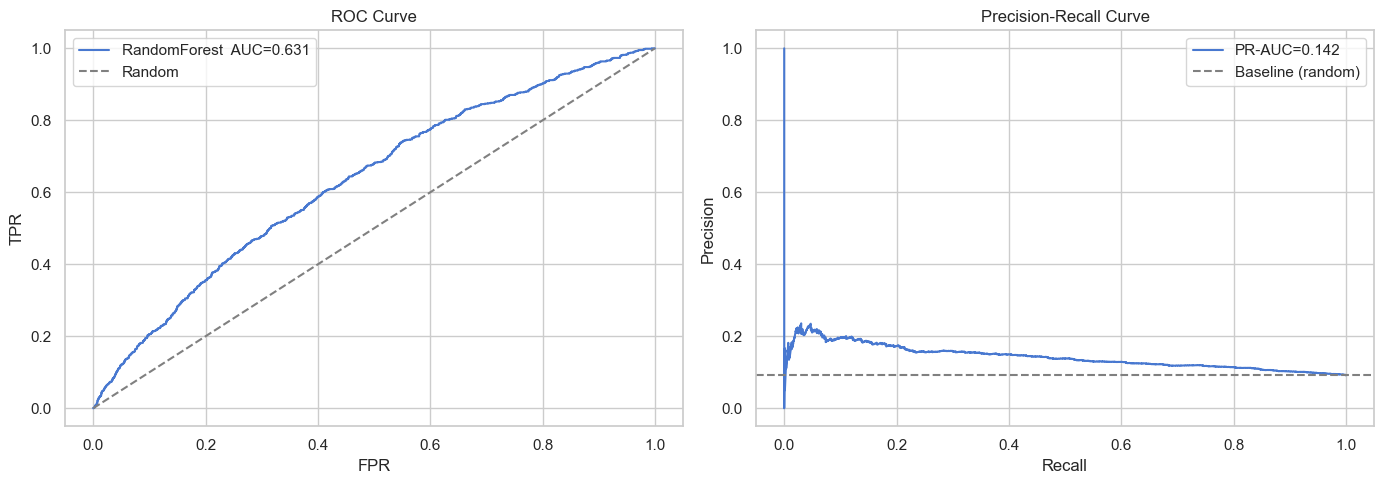

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
axes[0].plot(fpr, tpr, label=f'{best_model_name}  AUC={roc_auc_score(y_val, y_prob):.3f}')
axes[0].plot([0,1],[0,1],'--', color='grey', label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC Curve')
axes[0].legend()

# PR curve
prec, rec, _ = precision_recall_curve(y_val, y_prob)
axes[1].plot(rec, prec, label=f'PR-AUC={average_precision_score(y_val, y_prob):.3f}')
axes[1].axhline(y_val.mean(), color='grey', linestyle='--', label='Baseline (random)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'evaluation_curves.png', dpi=150)
plt.show()

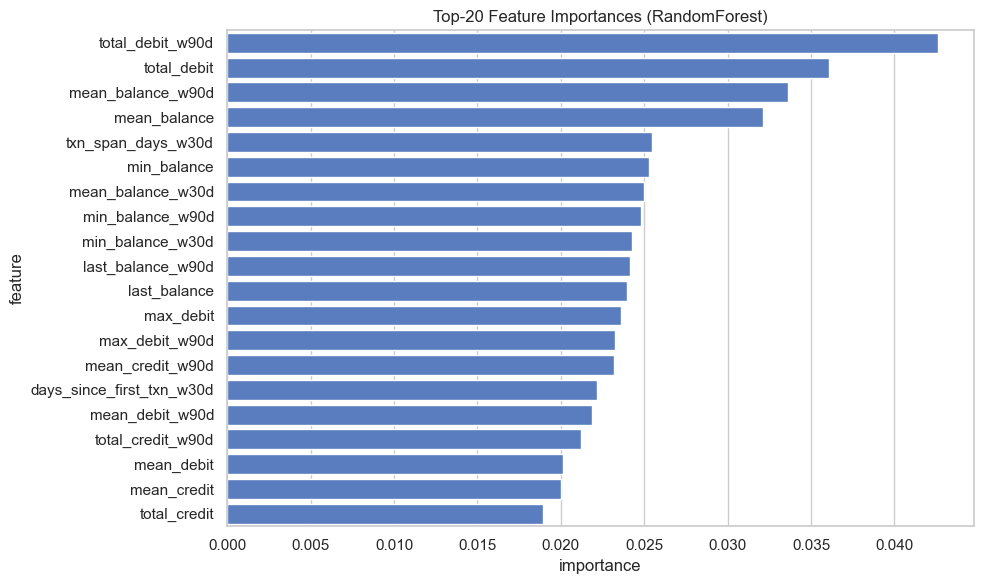

In [ ]:
# Feature importance (tree model only)
if hasattr(final_model['clf'], 'feature_importances_'):
    feat_names = final_model['pre'].get_feature_names_out()
    importances = final_model['clf'].feature_importances_
    
    feat_names = [f.split('__')[-1] for f in feat_names]
    
    feat_imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp_df, x='importance', y='feature')
    plt.title(f'Top-20 Feature Importances ({best_model_name})')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'feature_importances.png', dpi=150)
    plt.show()

## Threshold Selection

The default threshold of 0.5 is suboptimal for imbalanced datasets. 
We select the threshold that maximises the **F1-score** on the validation set as a balanced precision-recall trade-off.

Optimal threshold (max F1): 0.5103
At threshold 0.5103:
              precision    recall  f1-score   support

 Non-default       0.93      0.75      0.83      8180
     Default       0.15      0.43      0.22       826

    accuracy                           0.72      9006
   macro avg       0.54      0.59      0.52      9006
weighted avg       0.86      0.72      0.77      9006



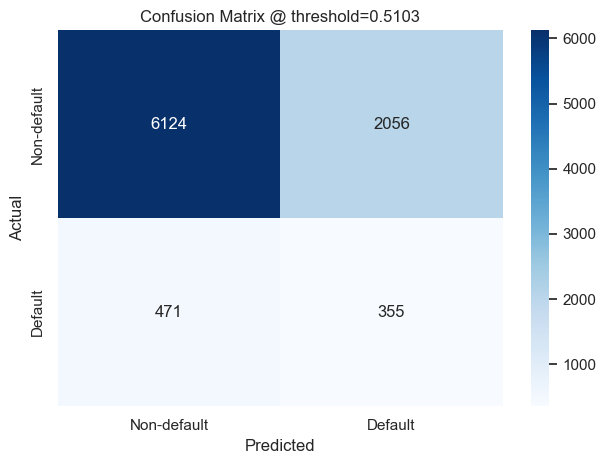

In [ ]:
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_val, y_prob)
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)

best_idx   = np.argmax(f1_arr)
THRESHOLD  = float(thresh_arr[best_idx])

print(f'Optimal threshold (max F1): {THRESHOLD:.4f}')
print(f'At threshold {THRESHOLD:.4f}:')
y_pred_thresh = (y_prob >= THRESHOLD).astype(int)
print(classification_report(y_val, y_pred_thresh, target_names=['Non-default', 'Default']))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_thresh)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-default','Default'], yticklabels=['Non-default','Default'])
plt.title(f'Confusion Matrix @ threshold={THRESHOLD:.4f}')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## OOT predictions + submission csv

In [ ]:
oot_probs = final_model.predict_proba(X_oot)[:, 1]

submission = pd.DataFrame({
    'decision_id' : oot['decision_id'].values,
    'predicted_PD': oot_probs,
})

out_path = OUTPUT_DIR / 'predictions_oot.csv'
submission.to_csv(out_path, index=False)

print(f'OOT predictions saved → {out_path}')
print(f'Shape: {submission.shape}')
submission.describe()

OOT predictions saved → output/predictions_oot.csv
Shape: (6041, 2)


,predicted_PD
count,6041.000000
mean,0.448068
std,0.117208
min,0.128633
25%,0.372803
50%,0.441854
75%,0.525010
max,0.770214


In [22]:
model_path = OUTPUT_DIR / 'pd_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump({
        'model'    : final_model,
        'threshold': THRESHOLD,
        'features' : numeric_features,
    }, f)

print(f'Model saved → {model_path}')

Model saved → output/pd_model.pkl


##  Model Inference

In [ ]:
def load_and_infer(
    flag_base_path: str,
    txn_ledger_path: str,
    model_path: str = str(OUTPUT_DIR / 'pd_model.pkl'),
) -> pd.DataFrame:
    """
    input
    flag_base_path: path to assignment_flag_base.csv
    txn_ledger_path: path to assignment_txn_ledger.csv
    model_path:     path to saved pd_model.pkl

    return
    pd.DataFrame with decision_id, predicted_PD, predicted_class
    """
    import pickle
    import pandas as pd
    import numpy as np

    flag = pd.read_csv(flag_base_path,  parse_dates=['decision_date', 'decision_date_full'])
    ledger = pd.read_csv(txn_ledger_path, parse_dates=['decision_date', 'txnDate'])

    # mirror training piplein
    decision_dates = flag[['decision_id', 'decision_date']].drop_duplicates()
    ledger = ledger.merge(decision_dates, on='decision_id', how='left', suffixes=('', '_flag'))
    ledger['days_before'] = (ledger['decision_date'] - ledger['txnDate']).dt.days
    ledger = ledger[ledger['days_before'] >= 0]

    feat_all = build_features(ledger)
    feat_30d = build_features(ledger, window_days=30)
    feat_90d = build_features(ledger, window_days=90)

    master = flag.copy()
    for feat_df in [feat_all, feat_30d, feat_90d]:
        master = master.merge(feat_df, on='decision_id', how='left')

    master['decision_date'] = pd.to_datetime(master['decision_date'], errors='coerce')
    master['decision_date_full'] = pd.to_datetime(master['decision_date_full'], errors='coerce')

    master['decision_month']     = master['decision_date'].dt.month
    master['decision_dayofweek'] = master['decision_date'].dt.dayofweek
    master['decision_hour']      = master['decision_date_full'].dt.hour

    with open(model_path, 'rb') as fh:
        artifacts = pickle.load(fh)
    model     = artifacts['model']
    threshold = artifacts['threshold']
    features  = artifacts['features']

    X = master[features]
    probs = model.predict_proba(X)[:, 1]

    result = pd.DataFrame({
        'decision_id'    : master['decision_id'],
        'predicted_PD'   : probs,
        'predicted_class': (probs >= threshold).astype(int),
    })
    return result


inference_result = load_and_infer(
    flag_base_path  = str(DATA_DIR / 'assignment_flag_base.csv'),
    txn_ledger_path = str(DATA_DIR / 'assignment_txn_ledger.csv'),
)
print(inference_result.head())
print(f'\nThreshold used: {THRESHOLD:.4f}')

Inference smoke-test passed.
                            decision_id  predicted_PD  predicted_class
0  b3e8cbd1-f940-4216-9ba2-a8cca1cbb791      0.206943                0
1  1a5b48c4-f715-4de6-af2f-025daa4598ba      0.163522                0
2  3dabb0db-2c29-4a93-8a8c-784607a9f639      0.507228                0
3  a40af4f7-7890-4a0b-8895-7034394992c2      0.520895                1
4  19d5e4fb-d045-4033-b3c4-88507acf43ab      0.376196                0

Threshold used: 0.5103


## Improvements ?
Well instead of having a metric driven threshold, examine costs of False +ve and False -ve
As even with good offline eval, this could suck in an online AB experiment